In [2]:
import pandas as pd
import numpy as np


In [3]:
table = pd.read_csv('/content/placement.csv')

In [4]:
table.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [5]:
table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [9]:
table.shape

(100, 4)

In [11]:
table.iloc[ : , 1:]

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0
...,...,...,...
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1
98,6.3,103.0,1


In [12]:
import matplotlib.pyplot as mtl

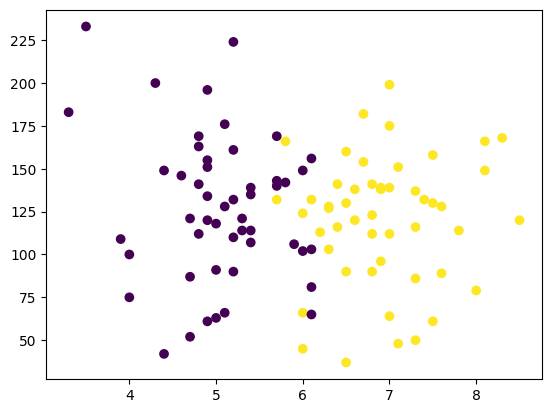

In [15]:
mtl.scatter(table['cgpa'] , table['iq'] , c=table['placement'])

In [23]:
x = table.iloc[: , 0:2]
y = table.iloc[: , -1]


In [26]:
x


,Unnamed: 0,cgpa
0,0,6.8
1,1,5.9
2,2,5.3
3,3,7.4
4,4,5.8
...,...,...
95,95,4.3
96,96,4.4
97,97,6.7
98,98,6.3


In [27]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [41]:
from sklearn.model_selection import train_test_split

train_x , test_x , train_y , test_y = train_test_split(x , y , test_size = 0.1)

In [45]:
test_y


,placement
8,0
35,1
74,1
66,1
37,1
14,0
85,1
71,1
53,1
80,0


In [69]:
from sklearn.preprocessing import StandardScaler

scalerobj = StandardScaler()
train_x = scalerobj.fit_transform(train_x)




In [71]:
test_x = scalerobj.fit_transform(test_x)

In [72]:
train_x


array([[ 0.199411  ,  1.65056089],
       [-1.48204693, -0.19861521],
       [ 1.33182144, -1.34334327],
       [-0.93299944, -0.90306325],
       [-1.58499333,  1.29833687],
       [-0.21237462,  0.77000084],
       [-1.10457678, -2.31195932],
       [-0.10942821, -0.55083923],
       [-1.68793974,  0.77000084],
       [-0.24669009,  1.47444888],
       [ 0.47393474,  0.32972082],
       [-0.69279117,  0.94611285],
       [ 0.50825021,  0.94611285],
       [ 1.2631905 , -0.72695124],
       [-1.31046959,  0.85805684],
       [-0.28100555, -0.46278322],
       [-1.03594585, -0.63889523],
       [-0.38395196,  0.50583283],
       [-0.52121383, -0.99111925],
       [ 0.64551208, -1.69556729],
       [-1.5163624 ,  1.03416885],
       [-1.27615412, -0.46278322],
       [ 1.53771424, -1.07917526],
       [-0.5555293 ,  0.0655528 ],
       [-0.31532102, -0.90306325],
       [ 1.46908331, -0.63889523],
       [-0.34963649, -1.16723126],
       [ 0.09646459,  0.94611285],
       [ 1.40045237,

In [73]:
test_x

array([[-1.69781655, -0.49102451],
       [-0.66302994,  0.2250529 ],
       [ 0.83166183,  0.12275613],
       [ 0.52505839,  0.32734967],
       [-0.58637908,  1.55491093],
       [-1.46786397, -0.49102451],
       [ 1.25324156, -0.79791482],
       [ 0.71668554, -0.49102451],
       [ 0.0268278 ,  1.75950448],
       [ 1.06161441, -1.71858577]])

In [93]:
from sklearn.linear_model import LogisticRegression
modeltraining =  LogisticRegression()

modeltraining.fit(train_x , train_y)

LogisticRegression()

In [94]:
pred_y =modeltraining.predict(test_x)

In [90]:
pred_y


array([ 0.22437808,  0.55257071,  0.55281068,  0.62930098,  1.10913466,
        0.23097553,  0.181115  ,  0.29365129,  1.21201475, -0.20817389])

In [95]:
from sklearn.metrics import accuracy_score

score = accuracy_score(test_y , pred_y)

In [96]:
score

0.8

<Axes: >

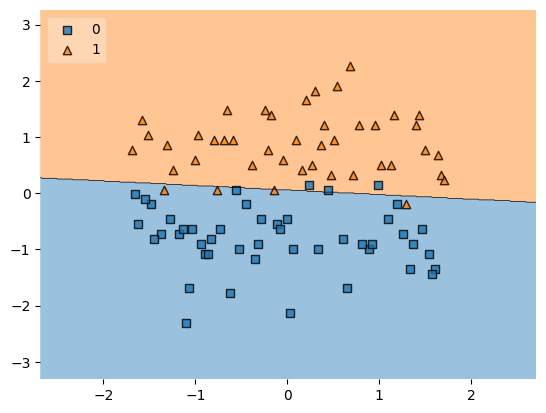

In [100]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(train_x , train_y.values,clf=modeltraining , legend = 2)